# Selección de Factores


* Correlaciones:  relaciones lineales entre variables numéricas







In [1]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica



# 1. Preparación de datos

In [2]:
#Cargamos los datos
data=pd.read_csv('titanic.csv', sep=',')
data.head()

,Clase,Edad,Sexo,Sobrevivio
0,primera,adulto,hombre,si
1,primera,adulto,hombre,si
2,primera,adulto,hombre,si
3,primera,adulto,hombre,si
4,primera,adulto,hombre,si


In [3]:
data=data.astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2201 entries, 0 to 2200
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Clase       2201 non-null   category
 1   Edad        2201 non-null   category
 2   Sexo        2201 non-null   category
 3   Sobrevivio  2201 non-null   category
dtypes: category(4)
memory usage: 9.3 KB


<Axes: xlabel='Sobrevivio'>

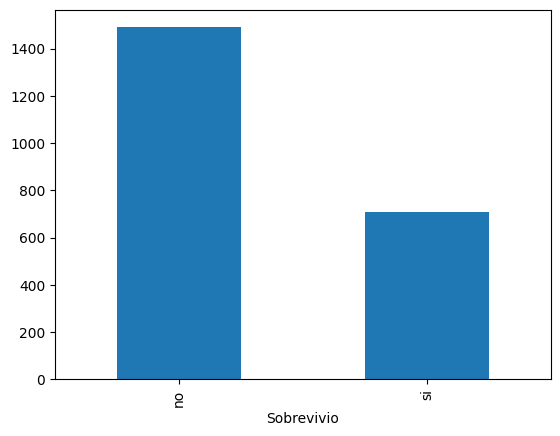

In [4]:
#Conocemos las variables categóricas
data['Sobrevivio'].value_counts().plot(kind='bar')

<Axes: xlabel='Sexo'>

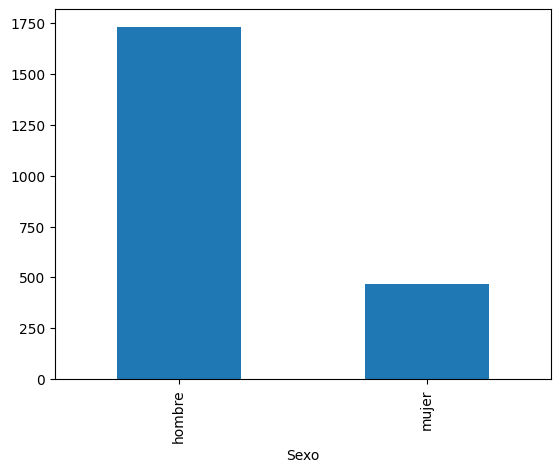

In [5]:
#Conocemos las variables categóricas
data['Sexo'].value_counts().plot(kind='bar')

<Axes: xlabel='Edad'>

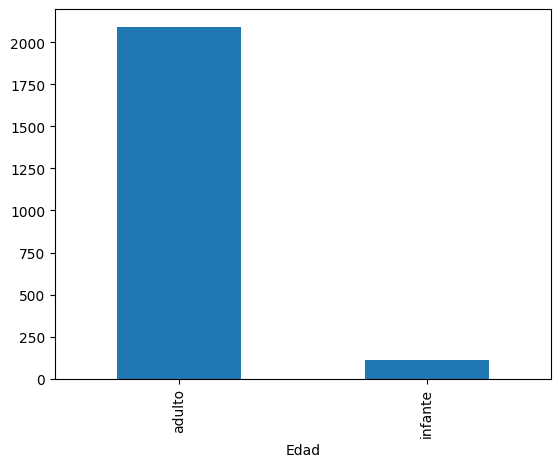

In [6]:
#Conocemos las variables categóricas
data['Edad'].value_counts().plot(kind='bar')

<Axes: xlabel='Clase'>

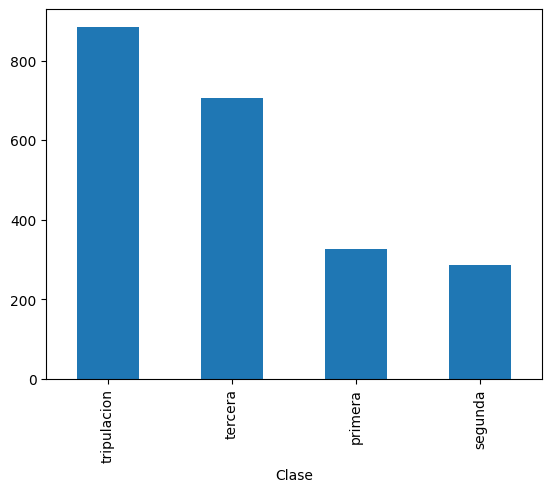

In [7]:
#Conocemos las variables categóricas
data['Clase'].value_counts().plot(kind='bar')

In [9]:
# Transformaciones
# Convertimos a número todas las variables (incluyendo la objetivo)

#Variable  de 2 categorías: se elimina una
#Variable  de 3 o más categorías: no se elimina

#Dummies para variable con más de 2 categorías
data = pd.get_dummies(data, columns=['Clase'], drop_first=False, dtype=int) #No se borra

#Dummies para variable con 2 categorías
data = pd.get_dummies(data, columns=['Edad', 'Sexo','Sobrevivio'],  drop_first=True, dtype=int)#Si se borra

data.head()

,Clase_primera,Clase_segunda,Clase_tercera,Clase_tripulacion,Edad_infante,Sexo_mujer,Sobrevivio_si
0,1,0,0,0,0,0,1
1,1,0,0,0,0,0,1
2,1,0,0,0,0,0,1
3,1,0,0,0,0,0,1
4,1,0,0,0,0,0,1


In [10]:
# Correlaciones
correlaciones=data.corr()
correlaciones

,Clase_primera,Clase_segunda,Clase_tercera,Clase_tripulacion,Edad_infante,Sexo_mujer,Sobrevivio_si
Clase_primera,1.000000,-0.160528,-0.286027,-0.341326,-0.059590,0.236257,0.268423
Clase_segunda,-0.160528,1.000000,-0.265037,-0.316278,0.061663,0.149065,0.075051
Clase_tercera,-0.286027,-0.265037,1.000000,-0.563541,0.197569,0.107457,-0.104204
Clase_tripulacion,-0.341326,-0.316278,-0.563541,1.000000,-0.187187,-0.375305,-0.146405
Edad_infante,-0.059590,0.061663,0.197569,-0.187187,1.000000,0.111013,0.097575
Sexo_mujer,0.236257,0.149065,0.107457,-0.375305,0.111013,1.000000,0.455605
Sobrevivio_si,0.268423,0.075051,-0.104204,-0.146405,0.097575,0.455605,1.000000


In [11]:
#Correlaciones con la variable de interés
cor_variable_interes=correlaciones.loc['Sobrevivio_si']
cor_variable_interes

,Sobrevivio_si
Clase_primera,0.268423
Clase_segunda,0.075051
Clase_tercera,-0.104204
Clase_tripulacion,-0.146405
Edad_infante,0.097575
Sexo_mujer,0.455605
Sobrevivio_si,1.000000


<BarContainer object of 7 artists>

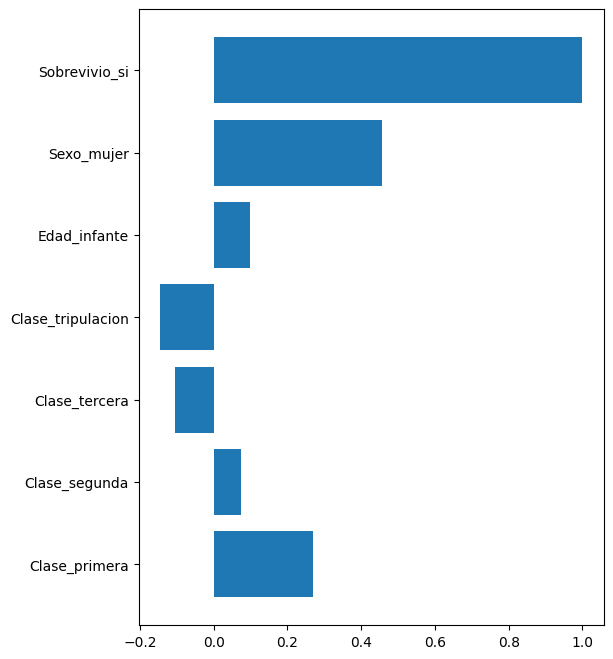

In [12]:
plt.figure(figsize=(6, 8))
plt.barh(y = data.columns, width=cor_variable_interes)

# 2. Correlaciones: relaciones lineales

* No se normaliza

# 3. Interpretación